# Data Cleaning Pipeline & Exploratory Data Analysis

Checks for:
- Missing Values
- Duplicates
- Languages
- Length & Structure
- Outliers

Produces initial analyses for:
- engagement/controversiality KPIs
- feature correlation
- language frequencies

Saves preprocessed and augmented versions of:
- videos_df
- comments_df

In [266]:
#%pip install plotly
#%pip install statsmodels

## Select query slug and load data

In [267]:
from pathlib import Path
raw_base = Path("data/raw")

# Display all available queries:
available_queries = [
    folder.name
    for folder in raw_base.iterdir()
    if folder.is_dir()
]

print(available_queries)

['alibaba_review', 'dhl_logistik_experiences_erfahrungen', 'etsy_experiences', 'zalando_review']


In [268]:
# Select query slug:
query_slug = 'zalando_review'

In [269]:
# Import libraries:

import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re
import plotly.express as px
from pathlib import Path

In [270]:
# Load metadata
raw_path = Path("data/raw") / query_slug

with open(raw_path / "metadata.json") as f:
    metadata = json.load(f)

In [271]:
# Load relevant Dataframes from .csv files:

videos_df = pd.read_csv(raw_path / "videos.csv")
comments_df = pd.read_csv(raw_path / "comments.csv")

## Data overview and missing values

In [272]:
videos_df.info()
videos_df.isna() # 3 videos have no description, we still keep them for now
videos_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   video_id       50 non-null     object
 1   title          50 non-null     object
 2   description    41 non-null     object
 3   channel        50 non-null     object
 4   published_at   50 non-null     object
 5   view_count     50 non-null     int64 
 6   like_count     50 non-null     int64 
 7   comment_count  50 non-null     int64 
 8   query_origin   50 non-null     object
 9   query_slug     50 non-null     object
 10  year           50 non-null     int64 
 11  month          50 non-null     int64 
 12  calendar_week  50 non-null     int64 
 13  weekday        50 non-null     object
dtypes: int64(6), object(8)
memory usage: 5.6+ KB


,view_count,like_count,comment_count,year,month,calendar_week
count,50.000000,50.00000,50.000000,50.000000,50.000000,50.000000
mean,9953.700000,152.10000,18.760000,2022.720000,6.080000,24.740000
std,18004.204865,398.22654,70.460456,2.878775,3.474925,14.810104
min,32.000000,0.00000,0.000000,2011.000000,1.000000,3.000000
25%,447.750000,1.50000,0.000000,2021.000000,3.000000,12.000000
50%,2188.000000,15.50000,2.000000,2023.500000,6.000000,25.000000
75%,8730.250000,103.25000,11.750000,2025.000000,9.750000,40.000000
max,68836.000000,2518.00000,496.000000,2026.000000,12.000000,52.000000


In [273]:
comments_df.info()
comments_df.isna()
comments_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   comment_id     400 non-null    object
 1   video_id       400 non-null    object
 2   author         400 non-null    object
 3   text           400 non-null    object
 4   like_count     400 non-null    int64 
 5   published_at   400 non-null    object
 6   reply_count    400 non-null    int64 
 7   query_origin   400 non-null    object
 8   query_slug     400 non-null    object
 9   year           400 non-null    int64 
 10  month          400 non-null    int64 
 11  calendar_week  400 non-null    int64 
 12  weekday        400 non-null    object
dtypes: int64(5), object(8)
memory usage: 40.8+ KB


,like_count,reply_count,year,month,calendar_week
count,400.000000,400.000000,400.00000,400.000000,400.0000
mean,1.752500,0.360000,2020.41000,5.740000,22.9725
std,9.671613,1.028613,4.59289,2.999983,12.7571
min,0.000000,0.000000,2011.00000,1.000000,1.0000
25%,0.000000,0.000000,2019.00000,3.000000,13.0000
50%,0.000000,0.000000,2020.00000,6.000000,23.0000
75%,1.000000,0.000000,2024.00000,8.000000,31.0000
max,158.000000,11.000000,2026.00000,12.000000,53.0000


In [274]:
text_columns = [
    "title",
    "description"
]
videos_df[text_columns] = (
    videos_df[text_columns]
    .fillna("")
)
comments_df["text"] = (
    comments_df["text"]
    .fillna("")
)

In [275]:
print(videos_df.dtypes)
videos_df.select_dtypes(include="object").head(10)

video_id         object
title            object
description      object
channel          object
published_at     object
view_count        int64
like_count        int64
comment_count     int64
query_origin     object
query_slug       object
year              int64
month             int64
calendar_week     int64
weekday          object
dtype: object


,video_id,title,description,channel,published_at,query_origin,query_slug,weekday
0,nBY9OwWxvX4,Zalando vs. PayPal Aktie - Welche Turnaround-W...,"Inflation, Konsumwandel und KI setzen selbst g...",onvista,2026-05-26 15:17:34+00:00,Zalando review,zalando_review,Tuesday
1,gFnR-Kcia6c,Zalando Finds Under €30 | Budget Fashion Haul ...,,Asmita Chawla,2025-07-23 07:35:32+00:00,Zalando review,zalando_review,Wednesday
2,SCl6TffbNM4,Zalando Platform Review – Reliable Fashion Pla...,Zalando.co.uk — the popular online fashion sto...,Healthy GK,2025-11-21 09:09:50+00:00,Zalando review,zalando_review,Friday
3,A4QVXB79DPg,Zalando Review 2026 Is Zalando Legit or a Scam...,Wondering if Zalando is really legit in 2026? ...,Calderon Bridger,2025-11-22 15:17:43+00:00,Zalando review,zalando_review,Saturday
4,os5mnq8oarg,Wie Betrüger mit Zalando abzocken | hessenschau,Nikolas wurde fies abgezockt. Auf einer Second...,hessenschau,2023-08-08 17:30:29+00:00,Zalando review,zalando_review,Tuesday
5,opmKDF3cVp8,ZALANDO APP REVIEW - IS IT WORTH IT? (EXPLAINED),Some app reviews might have small mistakes or ...,TutorialLore,2025-07-03 05:46:30+00:00,Zalando review,zalando_review,Thursday
6,AGMD9_1yz1s,UNBOXING ZALANDO SHOES .. Support to the ...,,Mr.Brown5150,2019-11-07 14:02:56+00:00,Zalando review,zalando_review,Thursday
7,lV6JTO6RchE,I Zalando review as a Petite woman- is Zalando...,I reviewed @zalando as a Petite woman! Is it P...,"Glam, but first coffee",2023-03-25 13:30:19+00:00,Zalando review,zalando_review,Saturday
8,GdCwMh8YYfA,Zalando Finds #shorts #new #2023 #spring #fash...,Zalando Finds #shorts #new #2023 #spring #fash...,Shine Out 97,2023-03-22 17:00:15+00:00,Zalando review,zalando_review,Wednesday
9,TighEvgQPeI,ZALANDO HAUL 🛍 Which item would you keep? 🙈 #h...,,Michaela Nguyen,2024-02-27 17:28:31+00:00,Zalando review,zalando_review,Tuesday


In [276]:
# Check for duplicates:
print(videos_df["video_id"].duplicated().sum())
print(comments_df["comment_id"].duplicated().sum())

0
0


In [277]:
# Show Top10 most commented videos:

videos_df.sort_values(
    "comment_count",
    ascending=False
)[
    ["title", "comment_count"]
].head(10)

,title,comment_count
29,XXL Zalando FAIL Haul - Was behalte ich?,496
23,ZALANDO ADVENTSKALENDER 2025 UNBOXING 🎄✨,60
37,[Review] Watercolors Produkte von Zalando.de,58
21,"Zalando, Momox oder H&M? So bekommst du am mei...",43
4,Wie Betrüger mit Zalando abzocken | hessenschau,40
43,Naturkosmetik Review auf Zalando Beauty | Werbung,30
18,ZALANDO HAUL// ZALANDO REVIEW//HUMMEL//+ HOW T...,28
13,Review Deutsch 1 Zalando bis zu 80% Rabatt -...,26
36,Zalando Aktie vor MEGA Trendwende! GANN Analys...,25
49,Zalando im Sturzflug - jetzt short gehen! Trad...,20


In [278]:
# Show Top10 most liked videos:

videos_df.sort_values(
    "like_count",
    ascending=False
)[
    ["title", "like_count"]
].head(10)

,title,like_count
29,XXL Zalando FAIL Haul - Was behalte ich?,2518
9,ZALANDO HAUL 🛍 Which item would you keep? 🙈 #h...,1119
21,"Zalando, Momox oder H&M? So bekommst du am mei...",653
26,Zalando finds you must have,551
6,UNBOXING ZALANDO SHOES .. Support to the ...,416
8,Zalando Finds #shorts #new #2023 #spring #fash...,336
43,Naturkosmetik Review auf Zalando Beauty | Werbung,291
11,Winter Footwear Picks,261
36,Zalando Aktie vor MEGA Trendwende! GANN Analys...,179
23,ZALANDO ADVENTSKALENDER 2025 UNBOXING 🎄✨,179


In [279]:
# Discussion Activation Rate (DAR): "How strongly does the video activate its viewers to engage?"
# DAR = (comment_count + 0.3 * like_count) / view_count

videos_df["discussion_activation_rate"] = (
    (
        videos_df["comment_count"]
        + 0.3 * videos_df["like_count"]
    )
    /
    videos_df["view_count"]
)

videos_df.sort_values(
    "discussion_activation_rate",
    ascending=False
)[
    ["title", "discussion_activation_rate"]
].head(10)

,title,discussion_activation_rate
18,ZALANDO HAUL// ZALANDO REVIEW//HUMMEL//+ HOW T...,0.158261
23,ZALANDO ADVENTSKALENDER 2025 UNBOXING 🎄✨,0.043166
36,Zalando Aktie vor MEGA Trendwende! GANN Analys...,0.029856
0,Zalando vs. PayPal Aktie - Welche Turnaround-W...,0.027708
41,Zalando Prognose 2 Monate später | Analyse tra...,0.024052
7,I Zalando review as a Petite woman- is Zalando...,0.023846
29,XXL Zalando FAIL Haul - Was behalte ich?,0.018179
25,ZALANDO UNBOXING | ZALANDO HAUL TRY ON | NON ...,0.014245
37,[Review] Watercolors Produkte von Zalando.de,0.012104
31,Zalando: 200 Tage-Linie im Blick - vor den Qua...,0.011002


In [280]:
# Controversy / Conversational Tension Score (CTS): 
# "How much discussion relative to agreement does the video produce?"
# CTS = log1p(comment_count) - log1p(like_count)

videos_df["controversy_tension_score"] = (
    np.log1p(videos_df["comment_count"])
    -
    np.log1p(videos_df["like_count"])
)

videos_df.sort_values(
    "controversy_tension_score",
    ascending=False
)[
    ["title", "controversy_tension_score"]
].head(10)

,title,controversy_tension_score
13,Review Deutsch 1 Zalando bis zu 80% Rabatt -...,3.295837
20,ZALANDO ONLINE SHOP | ZALANDO UNBOXING | ZALAN...,1.386294
33,All these sneakers and Sambas are still a styl...,0.693147
30,Un-Laced | Episode One | Sneakers | Zalando,0.405465
28,Here’s why the #ZalandoAdventCalendar should b...,0.000000
22,Zalando App - How to Find Reviews | See What O...,0.000000
16,How to check the reviews of a product on Zalan...,0.000000
15,Zalando.co.uk Review: Is zalando uk Legit and ...,0.000000
14,Zalando Review: Is Zalando Legit | Is Zalando ...,0.000000
18,ZALANDO HAUL// ZALANDO REVIEW//HUMMEL//+ HOW T...,0.000000


In [281]:
# Show Top10 most replied to comments:

comments_df.sort_values(
    "reply_count",
    ascending=False
)[
    ["text", "reply_count"]
].head(10)

,text,reply_count
122,Jemand team kleiderkreisel?🖐,11
152,"Leuk voor je dat je zo veel in pr krijgt, maar...",7
375,Sehr spannend! Ich nutze fast nur noch Naturko...,7
377,Also jetzt mal eine blöde Frage aber wie kann ...,6
35,Warum hat er denn die Schuhe zurückgeschickt? ...,5
29,Falls er das wirklich via Vinted-Käuferschutz ...,5
281,Hast du dich eigentlich selbst schon mal gefra...,4
121,"getragenen Höschen verkaufen, würde Melissa b...",4
148,Wat leuk dat je de kalender al hebt! Ik ben be...,4
116,Ich wollte meine neu und ungetrage Sachen (von...,3


In [282]:
# Show Top10 most liked comments:

comments_df.sort_values(
    "like_count",
    ascending=False
)[
    ["text", "like_count"]
].head(10)

,text,like_count
122,Jemand team kleiderkreisel?🖐,158
121,"getragenen Höschen verkaufen, würde Melissa b...",93
25,Also Dropshipping geht eigentlich anders😢,30
117,also als besonders nachhaltig kann man H&M bei...,27
29,Falls er das wirklich via Vinted-Käuferschutz ...,20
166,this is everything but not y2k💀,19
382,Danke Anna! Für die Recherche und die tolle Au...,16
35,Warum hat er denn die Schuhe zurückgeschickt? ...,16
123,Auf Ebay verkaufen,16
26,"Naja, dann müssen die die Schuhe in einem Zal...",15


### Show Boxplots for the distribution of views, likes and comments using log scale

### Display Boxplots using .melt()

C:\Users\gkahl\AppData\Local\Temp\ipykernel_44552\784933101.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




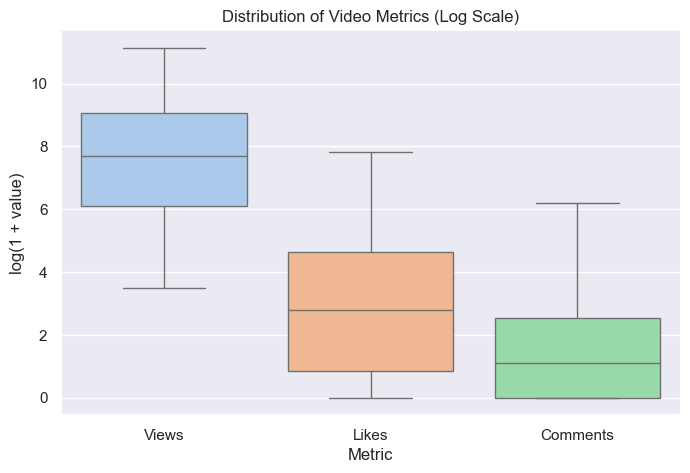

In [283]:
plot_df = pd.DataFrame({
    "Views": np.log1p(videos_df["view_count"]),
    "Likes": np.log1p(videos_df["like_count"]),
    "Comments": np.log1p(videos_df["comment_count"])
})
plot_df = plot_df.melt(
    var_name="Metric",
    value_name="Value"
)
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=plot_df,
    x="Metric",
    y="Value",
    palette="pastel"
)

plt.title("Distribution of Video Metrics (Log Scale)")
plt.ylabel("log(1 + value)")

plt.show()

<Axes: >

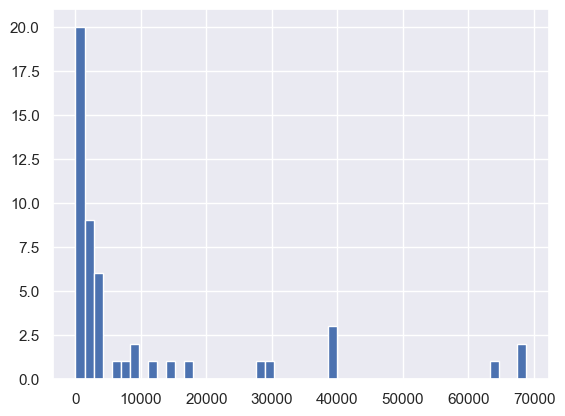

In [284]:
videos_df["view_count"].hist(bins=50)

<Axes: >

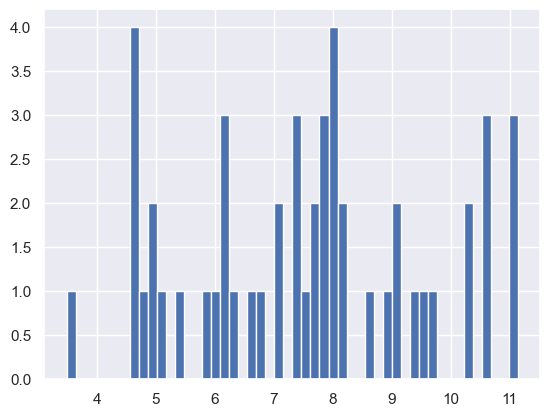

In [285]:
np.log1p(videos_df["view_count"]).hist(bins=50)

### Besides videos_df["comment_count"], which counts the number of comments on Youtube, we can also look at the number of comments that we have in our database for each of our videos.

In [286]:
comments_per_video = (
    comments_df
    .groupby("video_id")
    .size()
)

merged = comments_df.merge(
    videos_df,
    on="video_id",
    how="left"
)

merged.groupby("title").size().sort_values(ascending=False)

title
XXL Zalando FAIL Haul - Was behalte ich?                                                              100
[Review] Watercolors Produkte von Zalando.de                                                           58
ZALANDO ADVENTSKALENDER 2025 UNBOXING 🎄✨                                                               32
Wie Betrüger mit Zalando abzocken | hessenschau                                                        23
Zalando, Momox oder H&M? So bekommst du am meisten Geld für Kleidung! | SAT.1 Frühstücksfernsehen      23
ZALANDO HAUL// ZALANDO REVIEW//HUMMEL//+ HOW TO LABEL MY SON´S CLOTHING//Rubys Foreign Family          20
Zalando Prognose 2 Monate später | Analyse traf zu 100%                                                16
Zalando Aktie vor MEGA Trendwende! GANN Analyse zeigt den Wendepunkt 2025                              16
Zalando im Sturzflug - jetzt short gehen! Trading-Tipp                                                 14
Naturkosmetik Review auf Zalando Beauty 

# Exploratory Data Analysis: 

## How has engagement developed over time?

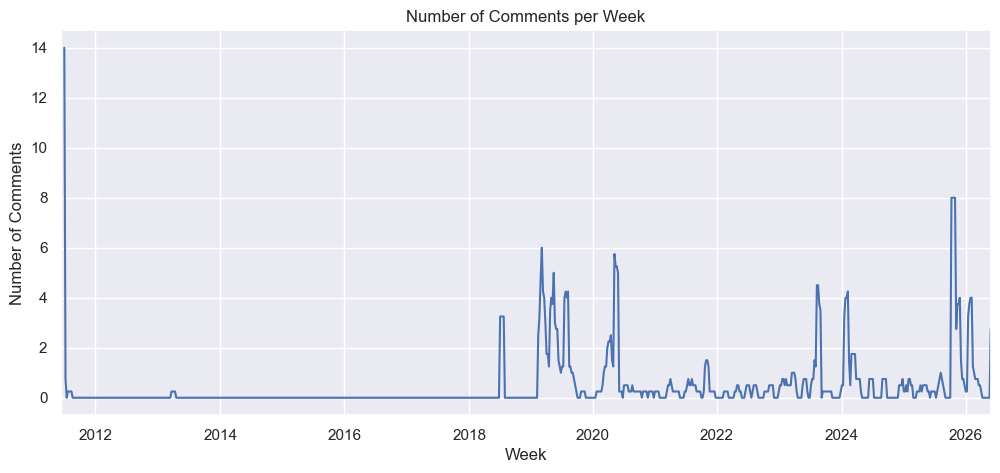

In [287]:
# Plot the comments over time

comments_df["published_at"] = pd.to_datetime(
    comments_df["published_at"]
)

comments_per_week = (
    comments_df
    .set_index("published_at")
    .resample("W")
    .size()
)

comments_per_week_smooth = (
    comments_per_week
    .rolling(4)
    .mean()
)

sns.set_theme(style="darkgrid")

plt.figure(figsize=(12, 5))

comments_per_week_smooth.plot()

plt.title("Number of Comments per Week")
plt.xlabel("Week")
plt.ylabel("Number of Comments")

plt.show()

## How are comments and likes correlated?

In [288]:
videos_df["log_like_count"] = np.log1p(
    videos_df["like_count"]
)

videos_df["log_comment_count"] = np.log1p(
    videos_df["comment_count"]
)

fig = px.scatter(
    videos_df,

    x="log_like_count",
    y="log_comment_count",


    hover_data=[
        "title"
    ],

    trendline="ols",

    title="Likes vs Comments (Log Scale)"
)

fig.show()

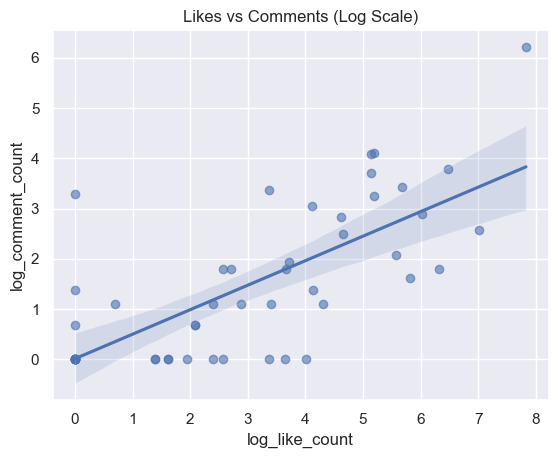

In [289]:
sns.regplot(
    data=videos_df,
    x="log_like_count",
    y="log_comment_count",
    scatter_kws={"alpha": 0.6}
)

plt.title("Likes vs Comments (Log Scale)")

plt.show()

In [290]:
# Log/log-Correlation between likes and comments
videos_df[
    ["log_like_count", "log_comment_count"]
].corr()

,log_like_count,log_comment_count
log_like_count,1.000000,0.723224
log_comment_count,0.723224,1.000000


In [291]:
videos_df[
    ["log_like_count", "log_comment_count"]
].corr(method="spearman")

,log_like_count,log_comment_count
log_like_count,1.000000,0.726221
log_comment_count,0.726221,1.000000


## Language detection and distribution (comments)

In [292]:
#%pip install langdetect
from langdetect import detect

In [293]:
def detect_language(text):

    try:
        return detect(str(text))

    except:
        return "unknown"
    
comments_df["language"] = (
    comments_df["text"]
    .apply(detect_language)
)

comments_df["language"].value_counts(normalize=True)

language
de         0.5475
en         0.1125
unknown    0.1050
nl         0.0700
tl         0.0300
af         0.0175
es         0.0150
et         0.0125
id         0.0125
da         0.0125
fr         0.0125
pt         0.0100
no         0.0100
ro         0.0050
sv         0.0050
so         0.0050
cs         0.0025
sw         0.0025
lt         0.0025
tr         0.0025
bn         0.0025
ca         0.0025
it         0.0025
Name: proportion, dtype: float64

In [294]:
videos_df["language"] = (
    videos_df["title"]
    .apply(detect_language)
)

print("The top video languages are:")
videos_df["language"].value_counts(normalize=True)

The top video languages are:


language
en    0.62
de    0.30
pl    0.02
fi    0.02
nl    0.02
es    0.02
Name: proportion, dtype: float64

In [295]:
# The top 5 languages in the comments are:
print("The top 5 languages in the comments are:")
comments_df["language"].value_counts().head(5)

The top 5 languages in the comments are:


language
de         219
en          45
unknown     42
nl          28
tl          12
Name: count, dtype: int64

C:\Users\gkahl\AppData\Local\Temp\ipykernel_44552\152886499.py:27: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




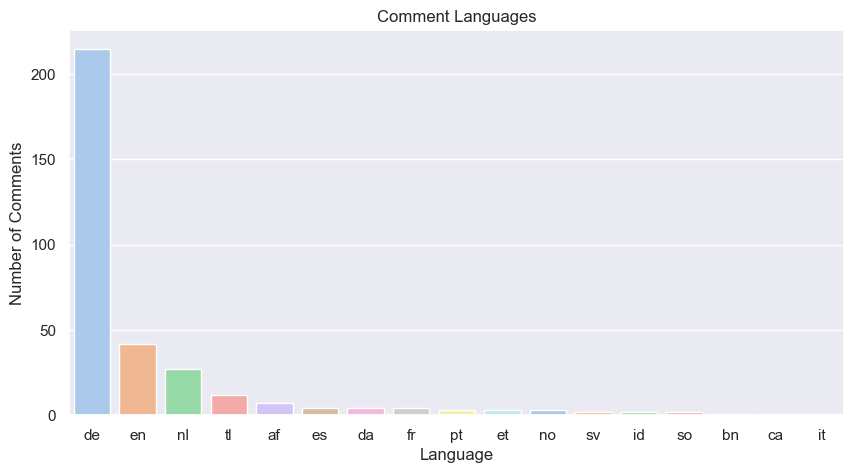

In [296]:
comments_df["text_length"] = (
    comments_df["text"]
    .astype(str)
    .str.len()
)

# Only consider comments with more than 15 characters to make the presentation more meaningful
language_df = comments_df[
    comments_df["text_length"] > 15
].copy()

sns.set_theme(style="darkgrid")

language_counts = (
    language_df["language"]
    .value_counts()
    .reset_index()
)

language_counts.columns = [
    "language",
    "count"
]

plt.figure(figsize=(10, 5))

sns.barplot(
    data=language_counts,
    x="language",
    y="count",
    palette="pastel"
)

plt.title("Comment Languages")
plt.xlabel("Language")
plt.ylabel("Number of Comments")

plt.show()

In [297]:
# Separate Dataframes for languages de and en:

#comments_de = comments_df[
#    comments_df["language"].isin(["de"])
#]
#comments_en = comments_df[
#    comments_df["language"].isin(["en"])
#]

In [298]:
# Which language gets the most likes on comments?
comments_df.groupby("language")[
    "like_count"
].mean().sort_values(ascending=False)

language
et         31.800000
de          1.917808
nl          1.535714
ro          1.500000
en          1.155556
af          1.000000
fr          0.800000
no          0.750000
so          0.500000
da          0.400000
es          0.333333
unknown     0.119048
lt          0.000000
bn          0.000000
id          0.000000
pt          0.000000
cs          0.000000
ca          0.000000
sv          0.000000
sw          0.000000
tl          0.000000
tr          0.000000
it          0.000000
Name: like_count, dtype: float64

## Let us now produce cleaned comment data for RAG applications:

In [299]:
# Copy the comments df:
comments_clean = comments_df.copy()

# Drop empty comments:
comments_clean = comments_clean.dropna(subset=["text"])
# Save text as string:
comments_clean["text"] = comments_clean["text"].astype(str)
# Drop duplicates:
comments_clean = comments_clean.drop_duplicates(subset=["comment_id"])
# Drop very short comments:
comments_clean["text_length"] = comments_clean["text"].str.len()
comments_clean = comments_clean[comments_clean["text_length"] >= 15]
# Consider only German and English comments:
comments_clean = comments_clean[comments_clean["language"].isin(["de", "en"])]

In [300]:

def clean_text(text):

    text = text.lower()

    # URLs entfernen
    text = re.sub(r"http\S+", "", text)

    # Mehrfache Whitespaces
    text = re.sub(r"\s+", " ", text)

    # Trim
    text = text.strip()

    return text

In [301]:
comments_clean["clean_text"] = comments_clean["text"].apply(clean_text)
comments_clean = comments_clean[comments_clean["clean_text"].str.len() > 0]
comments_clean.info()
comments_clean.sample(10)[["text", "clean_text"]]

<class 'pandas.core.frame.DataFrame'>
Index: 258 entries, 0 to 399
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   comment_id     258 non-null    object             
 1   video_id       258 non-null    object             
 2   author         258 non-null    object             
 3   text           258 non-null    object             
 4   like_count     258 non-null    int64              
 5   published_at   258 non-null    datetime64[ns, UTC]
 6   reply_count    258 non-null    int64              
 7   query_origin   258 non-null    object             
 8   query_slug     258 non-null    object             
 9   year           258 non-null    int64              
 10  month          258 non-null    int64              
 11  calendar_week  258 non-null    int64              
 12  weekday        258 non-null    object             
 13  language       258 non-null    object             
 14 

,text,clean_text
395,Hmmm ich würde eher auf nen Turaround apekulie...,hmmm ich würde eher auf nen turaround apekulie...
292,Moin.\nTradest du CFD bei deinen Aktientrades?...,moin. tradest du cfd bei deinen aktientrades? ...
351,@sandra0x3 soll jetzt kein scherz sein! vielle...,@sandra0x3 soll jetzt kein scherz sein! vielle...
303,ich werde nie verstehen wieso nicht alle lieds...,ich werde nie verstehen wieso nicht alle lieds...
397,"Ich bin gespannt, wie das ausgeht. Short-Empfe...","ich bin gespannt, wie das ausgeht. short-empfe..."
323,welchen nagellack trägst du ?,welchen nagellack trägst du ?
298,Ich möchte auch produkte im wert von 150 euro ...,ich möchte auch produkte im wert von 150 euro ...
363,Vielen Dank 🙏 \nWäre auch ein neues Update zu ...,vielen dank 🙏 wäre auch ein neues update zu si...
330,@Collchen14 ne ist bei mir auch so! YT hat heu...,@collchen14 ne ist bei mir auch so! yt hat heu...
365,Danke. Immer wieder neue und gute Infos. Weite...,danke. immer wieder neue und gute infos. weite...


## Save cleaned data in "processed" repository

In [302]:
from datetime import datetime

processed_path = Path("data/processed") / query_slug

processed_path.mkdir(parents=True, exist_ok=True) 

metadata = {
    "query_slug": query_slug,
    "processed_at": datetime.now().isoformat(),
    "language_filter": ["de", "en"],
    "duplicates_removed": True,
    "clean_text_created": True,
}

# Save metadata: 
with open(processed_path / "metadata.json", "w") as f: #"w" means write mode, file is being written 
    json.dump(metadata, f, indent=4) 
    
comments_clean.to_csv( 
    processed_path / "comments_clean.csv", 
    index=False 
    ) 

videos_df.to_csv(
    processed_path / "videos_clean.csv", 
    index=False 
    )

In [303]:
videos_df.columns

Index(['video_id', 'title', 'description', 'channel', 'published_at',
       'view_count', 'like_count', 'comment_count', 'query_origin',
       'query_slug', 'year', 'month', 'calendar_week', 'weekday',
       'discussion_activation_rate', 'controversy_tension_score',
       'log_like_count', 'log_comment_count', 'language'],
      dtype='object')